In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os,sys
cwd = os.getcwd()
sys.path.append(os.path.join(cwd,'../python'))
import threepoint

## Using the data class to output the measurement results to a fits file

In [89]:
# Initialize the 3pt data class
# The first argument is the name of the data
# The second is the bin_type, SSS stands for side-side-side 
#   (since map3 is parametrized by the 3 aperture radii, this can be interpreted as 
#   the 3 sides of a triangle effectively although three sides must not form triangle.)
thpt = threepoint.ThreePointDataClass('map3', 'SAS')

In [90]:
# Example:
################################ Preparing data as array ################################
# Redshift combinations
z = np.array([[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],[2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]])
z1, z2, z3 = z.T
nz = z1.size

# Aperture radii
t = np.array([7.0, 14.0, 25.0, 50.0])
t1 = t2 = t3 = t # same radii for map3 in our simplest setup
nt = t.size

## duplicate the zbin `nt` times because each zbin combination has `nt` data vector
z1 = np.repeat(z1, nt)
z2 = np.repeat(z2, nt)
z3 = np.repeat(z3, nt)

## Duplicate the tbin `nz` times, assuming the same aperture radii for all zbin combinations
t1 = np.tile(t1, nz)
t2 = np.tile(t2, nz)
t3 = np.tile(t3, nz)

# random signal
s = np.linspace(0, 1, nt*nz)

# random covariance
c = np.eye(nt*nz)
nsim = 400 # number of sims

################################ Putting data to the data class ################################
thpt.set_value(z1, z2, z3, t1, t2, t3, s)
thpt.set_covariance(c, nsim)

################################ Save the data ################################
thpt.to_fits('test.fits')

################################ Load the data ################################
thpt = threepoint.ThreePointDataClass.from_fits('test.fits')

## Using selection methods
Selection array can be obtained using the selection methods. Assume that `sel` to be the selection array obtained from some method. Then, you can choose the zbin, trignale bin, signal as follows:
```
z1, z2, z3 = thpt.get_z_bin(sel)
b1, b2, b3 = thpt.get_t_bin(sel)
s = thpt.get_signal(sel)
c = thpt.get_covariance(sel)
ic= thpt.get_inverse_covariance(sel)
```

In [91]:
thpt = threepoint.ThreePointDataClass.from_fits('test.fits')

In [92]:
# Redshift bin selection
# Example 1: select elements with z1==1
sel = thpt.selection_z_bin(1, 'z1', '==')
print(sum(sel))
# Example 2: select elements with z1>1
sel = thpt.selection_z_bin(1, 'z1', '>')
print(sum(sel))
# Example 3: select elements with z1==1 and z2==1 and z2==1
sel = thpt.selection_z_bin(1, 'z', '==')
print(sum(sel))
# Example 4: select elements with z1>1 and z2>1 and z2>1
sel = thpt.selection_z_bin(1, 'z', '>')
print(sum(sel))
# Example 5: select elements with z1==1 and z2==2 and z3==3
sel = thpt.selection_z_bin([1,2,3], ['z1', 'z2', 'z3'], '==')
print(sum(sel))

40
40
40
40
4


In [93]:
# Triangle bin selection for SSS bin_type
# Example 1: select elements with t1==7.0
sel = thpt.selection_SSS_bin(7.0, 'theta1', '==')
print(sum(sel))
# Example 2: select elements with t1>7.0
sel = thpt.selection_SSS_bin(7.0, 'theta1', '>')
print(sum(sel))
# Example 3: select elements with t1==7.0 and t2==7.0 and t3==7.0
sel = thpt.selection_SSS_bin(7.0, 'theta', '==')
print(sum(sel))
# Example 4: select elements with t1>7.0 and t2>7.0 and t3>7.0
sel = thpt.selection_SSS_bin(7.0, 'theta', '>')
print(sum(sel))
# Example 5: select elements with t1==7.0 and t2==14.0 and t3==25.0
sel = thpt.selection_SSS_bin([7.0,14.0,25.0], ['theta1', 'theta2', 'theta3'], '==')
print(sum(sel))

AssertionError: This method is only applicable for SSS bin type.

## Ordering the entries nicely
If you are lazy and make the order of entries messy, then you can sort the entries using the `sort` method.

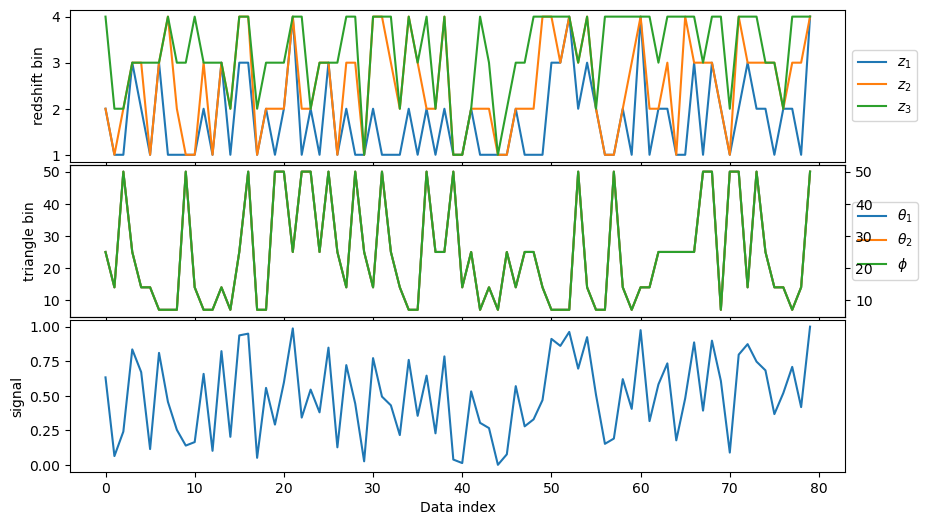

In [101]:
# shuffle the order of data
rng = np.random.default_rng(0)
o = rng.permutation(thpt.size)
thpt.replace(o)

# Data ordering before sort
fig = thpt.plot()

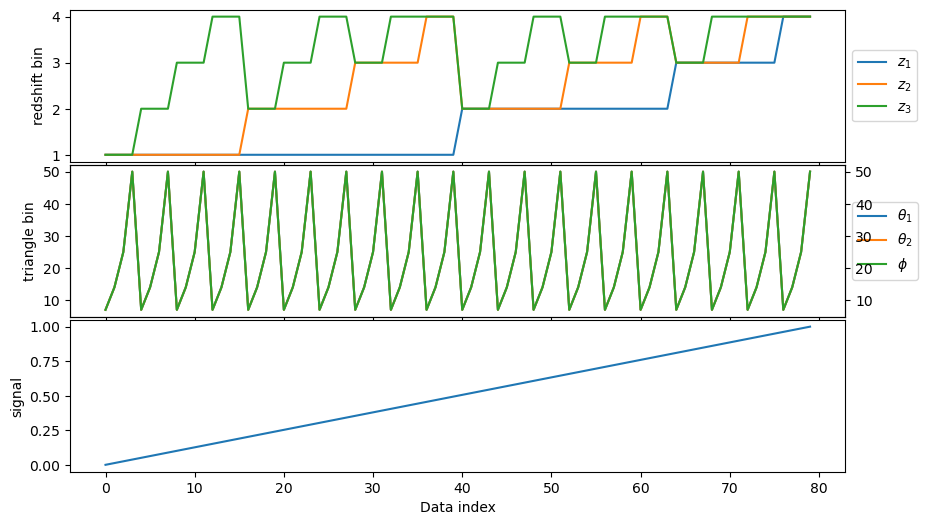

In [102]:
thpt = thpt.sort()
fig = thpt.plot()

## Usage in likelihood
Consider the case where we want assign the model prediction to this class instance.

In [103]:
model = thpt.copy()

In [104]:
def predict(z1, z2, z3, t1, t2, t3):
    return (z1 + z2 + z3)*(t1 + t2 + t3)

for z1, z2, z3 in model.get_z_bin(unique=True).T:
    # get aperture radii for this redshift-bin combination
    sel = model.selection_z_bin([z1, z2, z3], 'z123')
    t1, t2, t3 = model.get_t_bin(sel)
    # predict signal
    s = predict(z1, z2, z3, t1, t2, t3)
    model.set_value(z1, z2, z3, t1, t2, t3, s, sel)

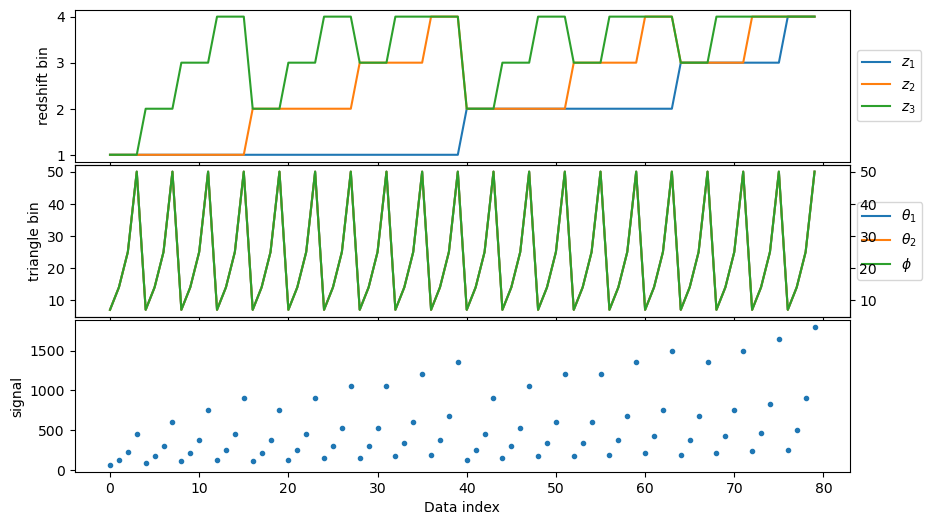

In [116]:
fig = model.plot(errorbar=True)

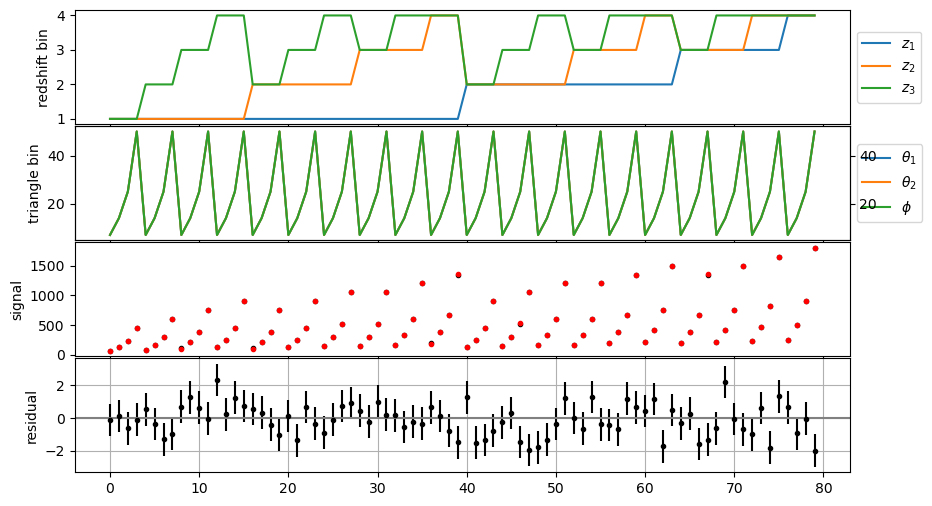

In [122]:
rng = np.random.default_rng(0)
s = rng.multivariate_normal(model.get_signal(), model.get_covariance(), size=1)[0]
fig = model.plot_residual(s, errorbar=True)

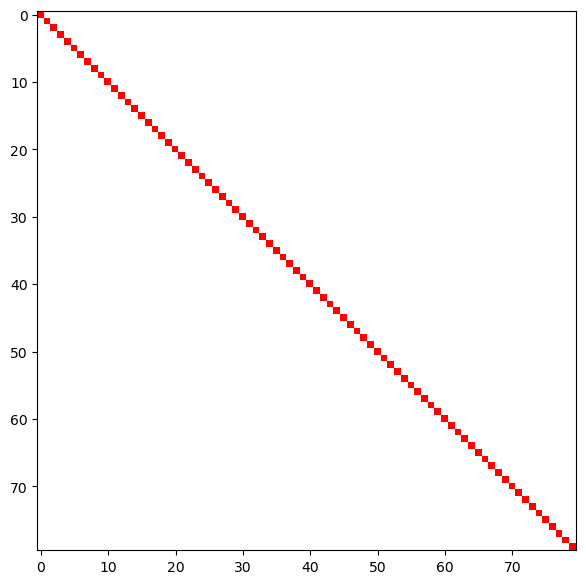

In [109]:
fig = thpt.plot_rcc()